# Tune beam current and trajectory through RFQ

In [1]:
import os
import time
import datetime
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict

# Point this notebook's EPICS client at the local simEPICS IOC.
# Set these before importing pyepics.
os.environ["EPICS_CA_ADDR_LIST"] = "127.0.0.1"
os.environ["EPICS_CA_AUTO_ADDR_LIST"] = "NO"

from epics import caput, caget, caget_many

def epics_text(value):
    """Normalize EPICS string PV values from scalar, bytes, or char-code arrays."""
    if isinstance(value, bytes):
        return value.decode(errors="ignore").rstrip("\x00")
    if isinstance(value, (int, float, np.integer, np.floating)):
        code = int(value)
        if float(value).is_integer() and 0 <= code < 256:
            return chr(code)
    if isinstance(value, np.ndarray):
        arr = value.ravel()
        if arr.size and np.issubdtype(arr.dtype, np.number):
            codes = [int(v) for v in arr if int(v) != 0]
            if codes and all(0 <= code < 256 for code in codes):
                return bytes(codes).decode(errors="ignore").rstrip("\x00")
        if arr.size == 1:
            return str(arr[0])
        return str(value)
    return str(value)


In [2]:
from pathlib import Path
import sys

def find_repo_root(start):
    for path in [start, *start.parents]:
        if (path / "stbo").is_dir() and (path / "examples").is_dir():
            return path
    raise RuntimeError(f"Could not find stBO repo root from {start}")

repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from stbo.optimization import BOController
from stbo.utils import live_monitor_plot, live_history_plot


In [3]:
machineio_repo = repo_root / "machineIO"
machineio_package = machineio_repo / "machineIO"
if not (machineio_package / "__init__.py").exists():
    raise RuntimeError(f"Could not find machineIO package under {machineio_repo}")

loaded_machineio = sys.modules.get("machineIO")
if loaded_machineio is not None:
    loaded_file = getattr(loaded_machineio, "__file__", None)
    loaded_is_expected = loaded_file is not None and str(Path(loaded_file).resolve()).startswith(str(machineio_package.resolve()))
    if not loaded_is_expected:
        for module_name in [name for name in list(sys.modules) if name == "machineIO" or name.startswith("machineIO.")]:
            del sys.modules[module_name]

if str(machineio_repo) not in sys.path:
    sys.path.insert(0, str(machineio_repo))

from machineIO import construct_machineIO, Evaluator, OracleEvaluator
from machineIO.objFunc import SingleTaskObjectiveFunction
from machineIO import preset


Failed to import 'phantasy'


In [4]:
sim_epics_required_pvs = [
    "ACS_DIAG:DEST:ACTIVE_ION_SOURCE",
    "FE_ISRC2:BEAM:ELMT_BOOK",
    "FE_ISRC2:BEAM:Q_BOOK",
    "FE_ISRC2:BEAM:A_BOOK",
    "GTS_FTS:MSTR_N0001:PCUR_DFAC_RD",
    "GTS_FTS:MSTR_N0001:MSG_RD_FSM",
    "GTS_FTS:MSTR_N0001:FR_CSET_REP",
    "ACS_DIAG:CHP:STATE_RD",
    "FE_LEBT:PSC2_D0964:I_CSET",
    "FE_LEBT:PSC1_D0964:I_CSET",
    "FE_LEBT:PSC2_D0979:I_CSET",
    "FE_LEBT:PSC1_D0979:I_CSET",
    "FE_LEBT:PSC2_D0992:I_CSET",
    "FE_LEBT:PSC1_D0992:I_CSET",
    "FE_LEBT:PSC2_D0964:I_RD",
    "FE_LEBT:PSC1_D0964:I_RD",
    "FE_LEBT:PSC2_D0979:I_RD",
    "FE_LEBT:PSC1_D0979:I_RD",
    "FE_LEBT:PSC2_D0992:I_RD",
    "FE_LEBT:PSC1_D0992:I_RD",
    "FE_MEBT:BPM_D1056:XPOS_RD",
    "FE_MEBT:BPM_D1056:YPOS_RD",
    "FE_MEBT:BPM_D1056:PHASE_RD",
    "FE_MEBT:BPM_D1072:PHASE_RD",
    "FE_MEBT:BPM_D1094:PHASE_RD",
    "FE_MEBT:BCM_D1055:AVGPK_RD",
    "FE_MEBT:FC_D1102:PKAVG_RD",
]

def check_sim_epics_pvs():
    values = caget_many(sim_epics_required_pvs)
    missing = [
        pv for pv, value in zip(sim_epics_required_pvs, values)
        if value is None
    ]
    return values, missing

sim_epics_values, missing_sim_epics_pvs = check_sim_epics_pvs()

if missing_sim_epics_pvs and len(missing_sim_epics_pvs) == len(sim_epics_required_pvs):
    print("No simEPICS PVs are visible. Starting the local simEPICS IOC in this kernel...")
    import json

    sim_epics_notebook = repo_root / "simEPICS" / "simulated_epics.ipynb"
    if not sim_epics_notebook.exists():
        raise FileNotFoundError(f"Could not find {sim_epics_notebook}")

    sim_epics_nb = json.loads(sim_epics_notebook.read_text(encoding="utf-8"))
    exec("".join(sim_epics_nb["cells"][1]["source"]), globals())
    time.sleep(1.0)
    sim_epics_values, missing_sim_epics_pvs = check_sim_epics_pvs()

if missing_sim_epics_pvs:
    raise AssertionError(
        "Some simEPICS PVs are still missing. If another simulator kernel is already "
        "running, restart it with the updated simEPICS/simulated_epics.ipynb. "
        f"Missing: {missing_sim_epics_pvs}"
    )

print(f"Verified {len(sim_epics_required_pvs)} simEPICS PVs for MEBT FC1102.")


No simEPICS PVs are visible. Starting the local simEPICS IOC in this kernel...
IOC running. PVs available:
 - ACS_DIAG:CHP:STATE_RD
 - ACS_DIAG:DEST:ACTIVE_ION_SOURCE
 - DIAG-RIO01:PICO_SWITCH2
 - DIAG-RIO01:TETRAMM_ENABLED1
 - FE_ISRC2:BEAM:A_BOOK
 - FE_ISRC2:BEAM:ELMT_BOOK
 - FE_ISRC2:BEAM:MOVRQ_BOOK
 - FE_ISRC2:BEAM:Q_BOOK
 - FE_LEBT:AP_D0796:IN_CMD
 - FE_LEBT:AP_D0796:LMIN_RSTS
 - FE_LEBT:AP_D0807:IN_CMD
 - FE_LEBT:AP_D0807:LMIN_RSTS
 - FE_LEBT:FC_D0814:IN_CMD_DRV
 - FE_LEBT:FC_D0814:LMPOS_RSTS_DRV
 - FE_LEBT:FC_D0977:IN_CMD_DRV
 - FE_LEBT:FC_D0977:LMPOS_RSTS_DRV
 - FE_LEBT:FC_D0998:IN_CMD
 - FE_LEBT:FC_D0998:LMOUT_RSTS
 - FE_LEBT:PSC1_D0948:I_CSET
 - FE_LEBT:PSC1_D0948:I_RD
 - FE_LEBT:PSC1_D0964:I_CSET
 - FE_LEBT:PSC1_D0964:I_RD
 - FE_LEBT:PSC1_D0979:I_CSET
 - FE_LEBT:PSC1_D0979:I_RD
 - FE_LEBT:PSC1_D0992:I_CSET
 - FE_LEBT:PSC1_D0992:I_RD
 - FE_LEBT:PSC2_D0948:I_CSET
 - FE_LEBT:PSC2_D0948:I_RD
 - FE_LEBT:PSC2_D0964:I_CSET
 - FE_LEBT:PSC2_D0964:I_RD
 - FE_LEBT:PSC2_D0979:I_CSET
 - 

# Prepare and Check machine status

##### check source and chopper setting

In [5]:
SCS = int(caget("ACS_DIAG:DEST:ACTIVE_ION_SOURCE"))
ion_name = epics_text(caget(f"FE_ISRC{SCS}:BEAM:ELMT_BOOK"))
Q = float(caget(f"FE_ISRC{SCS}:BEAM:Q_BOOK"))
A = float(caget(f"FE_ISRC{SCS}:BEAM:A_BOOK"))
# AQ = caget(f"FE_ISRC{SCS}:BEAM:MOVRQ_BOOK")
AQ = A / Q

A_label = int(A) if A.is_integer() else A
Q_label = int(Q) if Q.is_integer() else Q
ion = f"{A_label}{ion_name}{Q_label}"
print("SCS" + str(SCS), ion, "A/Q=", AQ)

duty = np.round(caget("GTS_FTS:MSTR_N0001:PCUR_DFAC_RD"), decimals=4)
mode = epics_text(caget("GTS_FTS:MSTR_N0001:MSG_RD_FSM"))
rep = caget("GTS_FTS:MSTR_N0001:FR_CSET_REP")

print(f"Mode: {mode}")
print(f"Rep Rate: {rep}Hz, Duty: {duty}%")


SCS2 238U37 A/Q= 6.4324324324324325
Mode: Ready
Rep Rate: 5.0Hz, Duty: 10.0%


##### check upstream FC

In [6]:
if SCS==1:
    upstream_FC_isoutPVs  = ['FE_SCS1:FC_D0739:LMPOS_RSTS_DRV']
    upstream_FC_insertPVs = ['FE_SCS1:FC_D0738:IN_CMD_DRV']
elif SCS==2:
    upstream_FC_isoutPVs  = ['FE_SCS2:FC_D0717:LMPOS_RSTS_DRV']
    upstream_FC_insertPVs = ['FE_SCS2:FC_D0717:IN_CMD_DRV']
    
upstream_FC_isoutPVs = upstream_FC_isoutPVs + ['FE_LEBT:FC_D0814:LMPOS_RSTS_DRV','FE_LEBT:FC_D0977:LMPOS_RSTS_DRV','FE_LEBT:FC_D0998:LMOUT_RSTS']
upstream_FC_insertPVs= upstream_FC_insertPVs+ ['FE_LEBT:FC_D0814:IN_CMD_DRV', 'FE_LEBT:FC_D0977:IN_CMD_DRV', 'FE_LEBT:FC_D0998:IN_CMD']
    
isCMDsent = False
for FC_isoutPV, FC_insertPV in zip(upstream_FC_isoutPVs, upstream_FC_insertPVs):
    is_FC_out = caget(FC_isoutPV)
    if not is_FC_out:
        r = input(f"FC {FC_insertPV.strip(':IN_CMD')} is inserted. Do you allow me to take it out? ")
        if r in ['yes','y','YES','Y']:
            caput(FC_insertPV,0)
            isCMDsent = True
if isCMDsent:
    time.sleep(10)
for FC_isoutPV, FC_insertPV in zip(upstream_FC_isoutPVs, upstream_FC_insertPVs):
    is_FC_out = caget(FC_isoutPV)
    if not is_FC_out:
        r = input(f"FC {FC_insertPV.strip(':IN_CMD')} is still inserted. please check manually. enter to continue")

##### check MEBT FC

In [7]:
is_FC_out = caget('FE_MEBT:FC_D1102:LMOUT_RSTS')
if is_FC_out:
    r = input("FE_MEBT:FC_D1102 is out. Do you allow me to insert it? ")
    if r in ['yes','y','YES','Y']:
        caput('FE_MEBT:FC_D1102:IN_CMD',1)
        time.sleep(5)
        is_FC_out = caget('FE_MEBT:FC_D1102:LMOUT_RSTS')
        if is_FC_out:
            r = input(f"FE_MEBT:FC_D1102 is still not inserted. please check manually. enter to continue")

# check MEBT FC range 1055 uA
if caget('FE_MEBT:FC_D1102:RNG_CMD') != 0:
    r = input("FE_MEBT:FC_D1102 range is set to 1uA. Do you want me to change too 1055 uA? ")
    if r in ['yes','y','YES','Y']:
        caput('FE_MEBT:FC_D1102:RNG_CMD',0)
        time.sleep(5)
        if caget('FE_MEBT:FC_D1102:RNG_CMD') != 0:
            r = input(f"FE_MEBT:FC_D1102 range is still not correct. please check manually.")
            
# check Pico vs TetrA
is_tetra = caget('DIAG-RIO01:TETRAMM_ENABLED1')
if is_tetra:
    r = input("FE_MEBT:FC_D1102 is in TetrA mode. Do you want me to switch to Pico mode? ")
    if r in ['yes','y','YES','Y']:
        caput('DIAG-RIO01:PICO_SWITCH2',0)
        time.sleep(5)
        is_tetra = caget('DIAG-RIO01:TETRAMM_ENABLED1')
        if is_tetra:
            r = input("FE_MEBT:FC_D1102 is still in TetrA mode. please check manually.")

##### check upstream apertures and attenuators

In [8]:
aperture_setPVs = ['FE_LEBT:AP_D0796:IN_CMD','FE_LEBT:AP_D0807:IN_CMD']
aperture_rdPVs  = ['FE_LEBT:AP_D0796:LMIN_RSTS','FE_LEBT:AP_D0807:LMIN_RSTS']
aperture_rd_targets = [1, 1]
aperture_rd_tols    = [0.1, 0.1]
isCMDsent = False
for i,pv in enumerate(aperture_rdPVs):
    pv_simple = pv.strip(':LMIN_RSTS').strip(':IN_CMD')
    target = aperture_rd_targets[i]
    val = caget(pv)
    tol = aperture_rd_tols[i]
    isin = target-tol < val < target+tol
    if not isin:
        r = input(f"aperture {pv_simple} is not inserted. Do you allow me to put it in? ")
        if r in ['yes','y','YES','Y']:
            caput(aperture_setPVs[i],target)
            print(f"aperture {pv_simple} is inserted")
if isCMDsent:
    time.sleep(3)
    for i,pv in enumerate(aperture_rdPVs):
        pv_simple = pv.strip(':LMIN_RSTS').strip(':IN_CMD')
        target = aperture_rd_targets[i]
        val = caget(pv)
        tol = aperture_rd_tols[i]
        isin = target-tol < val < target+tol
        if not isin:
            r = input(f"aperture {pv_simple} is still not inserted. please check manually. enter to continue")

##### check monitor PVs

# === Begin User Inputs ===

##### Define current at 100% transmission (FC814 reading)

In [9]:
maxBeamCurrent = 39.7

##### IO settings

In [10]:
data_acquire_rate = 5 # [Hz]
timespan_for_average = 2.0  # [sec]
additional_wait_after_powersupply_ramp  = 0.3 # [sec]

##### Optimizer setting 
Do not exceed budget 100. It will impractically slow down training and quering GP model

In [11]:
is_close_to_opt = True

if is_close_to_opt:
    n_init_budget       = 10   # recommended: about order of control parameters 
    n_global_opt_budget = 0
    n_local_opt_budget  = 50
    n_finetune_budget   = 8    # recommended: about order of control parameters 
else:
    n_init_budget       = 30          
    n_global_opt_budget = 30
    n_local_opt_budget  = 30
    n_finetune_budget   = 5    # recommended: less than number of control parameters 

_budget = n_init_budget +n_global_opt_budget +n_local_opt_budget +n_finetune_budget
_ramping_time = 2 # on average, each iter, considering polarity crossing time
_expected_oracle_time_cost = timespan_for_average + additional_wait_after_powersupply_ramp + _ramping_time
print(f"budget: {_budget}")
print(f"expected run time: {int(_budget*_expected_oracle_time_cost)} sec")

budget: 68
expected run time: 292 sec


### Define controls
to do list:
 - try a V-dipole instead of a V-corrector to avoid polarity crossing time
 - try solenoids 

In [12]:
control_CSETs= [
#     'FE_LEBT:PSC2_D0948:I_CSET', 'FE_LEBT:PSC1_D0948:I_CSET',
    'FE_LEBT:PSC2_D0964:I_CSET', 'FE_LEBT:PSC1_D0964:I_CSET',
    'FE_LEBT:PSC2_D0979:I_CSET', 'FE_LEBT:PSC1_D0979:I_CSET',
    'FE_LEBT:PSC2_D0992:I_CSET', 'FE_LEBT:PSC1_D0992:I_CSET',
]
control_RDs  = [pv.replace('_CSET','_RD') for pv in control_CSETs]

is_cryo = np.any(['_CB' in PV or '_CA' in PV or  '_CC' in PV or  '_CD' in PV or  '_CE' in PV for PV in control_CSETs])
if not is_close_to_opt and is_cryo:
    print('warn: global optimization is proposed with controls in croyo module. proceed with care')

In [13]:
x0 = caget_many(control_CSETs)
missing_controls = [pv for pv, value in zip(control_CSETs, x0) if value is None]
assert not missing_controls, f"Missing control CSET PVs from simEPICS: {missing_controls}"
x0 = np.asarray(x0, dtype=float)

control_tols = []
control_min = []
control_max = []
for v, PV in zip(x0, control_CSETs):
    if "PSC" in PV:
        control_min.append(v - 0.5 * AQ)
        control_max.append(v + 0.5 * AQ)
        control_tols.append(0.2)
    elif "PSOL" in PV:
        control_min.append(0.9 * v)
        control_max.append(1.1 * v)
        control_tols.append(1.0)
    else:
        raise ValueError(f"control bounds for {PV} cannot be determined")

assert len(control_CSETs) == len(control_min) == len(control_max) == len(control_tols)

try:
    control_Lo_limit, control_Hi_limit = preset.get_limits(control_CSETs)
    control_Lo_limit = np.asarray(control_Lo_limit, dtype=float)
    control_Hi_limit = np.asarray(control_Hi_limit, dtype=float)
except Exception as exc:
    print(f"Using simulator fallback control limits because preset.get_limits failed: {exc}")
    control_Lo_limit = np.full(len(control_CSETs), -5.5, dtype=float)
    control_Hi_limit = np.full(len(control_CSETs), 5.5, dtype=float)

invalid_limits = (
    ~np.isfinite(control_Lo_limit)
    | ~np.isfinite(control_Hi_limit)
    | (control_Lo_limit >= control_Hi_limit)
)
if np.any(invalid_limits):
    print("Using simulator fallback control limits for invalid DRVL/DRVH values.")
    control_Lo_limit = np.where(invalid_limits, -5.5, control_Lo_limit)
    control_Hi_limit = np.where(invalid_limits, 5.5, control_Hi_limit)

control_min = np.clip(control_min, a_min=control_Lo_limit, a_max=None)
control_max = np.clip(control_max, a_min=None, a_max=control_Hi_limit)
assert np.all(control_max > control_min)
control_bounds = torch.tensor([control_min.tolist(), control_max.tolist()], dtype=torch.float64)

print("============== check control bounds ================= ")
pd.DataFrame(
    np.array([x0, control_min, control_max, control_tols, control_Lo_limit, control_Hi_limit]).T,
    index=control_CSETs,
    columns=["current value", "control min", "control max", "tol", "LoLim", "HiLim"],
)


Using simulator fallback control limits because preset.get_limits failed: 
============== check control bounds ================= 


,current value,control min,control max,tol,LoLim,HiLim
FE_LEBT:PSC2_D0964:I_CSET,0.0,-3.216216,3.216216,0.2,-5.5,5.5
FE_LEBT:PSC1_D0964:I_CSET,0.0,-3.216216,3.216216,0.2,-5.5,5.5
FE_LEBT:PSC2_D0979:I_CSET,0.0,-3.216216,3.216216,0.2,-5.5,5.5
FE_LEBT:PSC1_D0979:I_CSET,0.0,-3.216216,3.216216,0.2,-5.5,5.5
FE_LEBT:PSC2_D0992:I_CSET,0.0,-3.216216,3.216216,0.2,-5.5,5.5
FE_LEBT:PSC1_D0992:I_CSET,0.0,-3.216216,3.216216,0.2,-5.5,5.5


### Define objectives

In [15]:
# BPM_snapshot_fname = '20260418_1152_238U37_17p3MeVu_2W_to_CSS_slitclosed.bpm'
# if BPM_snapshot_fname is not None:
#     objective_goal = preset.get_MEBT_objective_goal_from_BPMoverview(BPM_snapshot_fname)
#     objective_goal['FE_MEBT:BCM_D1055:AVGPK_RD'] = {'more than': 0.99*maxBeamCurrent},
#     objective_goal['FE_MEBT:FC_D1102:PKAVG_RD' ]  ={'more than':  0.8*maxBeamCurrent},
#     display(objective_goal)

In [16]:
objective_goal= {
    'FE_MEBT:BPM_D1056:XPOS_RD': 0.0,
    'FE_MEBT:BPM_D1056:YPOS_RD': 0.0,
    'FE_MEBT:BPM_D1056:PHASE_RD': 76.78251733880323,
    'FE_MEBT:BPM_D1072:XPOS_RD': 0.04461801988247305,
    'FE_MEBT:BPM_D1072:YPOS_RD': 0.14918937946766403,
    'FE_MEBT:BPM_D1072:PHASE_RD': -26.69204704418517,
    'FE_MEBT:BPM_D1094:XPOS_RD': -0.00830562782880001,
    'FE_MEBT:BPM_D1094:YPOS_RD': 0.10088006089580875,
    'FE_MEBT:BPM_D1094:PHASE_RD': -15.958044148322497,
    'FE_MEBT:BCM_D1055:AVGPK_RD': {'more than': 0.99*maxBeamCurrent},
    'FE_MEBT:FC_D1102:PKAVG_RD' : {'more than':  0.8*maxBeamCurrent},
}

In [17]:
objective_tolerance= {
    'FE_MEBT:BPM_D1056:XPOS_RD' : 1,  
    'FE_MEBT:BPM_D1056:YPOS_RD' : 1,
    'FE_MEBT:BPM_D1056:PHASE_RD': 1,
    'FE_MEBT:BPM_D1072:XPOS_RD' : 1,
    'FE_MEBT:BPM_D1072:YPOS_RD' : 1,
    'FE_MEBT:BPM_D1072:PHASE_RD': 1,
    'FE_MEBT:BPM_D1094:XPOS_RD' : 1,
    'FE_MEBT:BPM_D1094:YPOS_RD' : 1,
    'FE_MEBT:BPM_D1094:PHASE_RD': 1,
    'FE_MEBT:BCM_D1055:AVGPK_RD': 0.02*maxBeamCurrent,
    'FE_MEBT:FC_D1102:PKAVG_RD' : 0.05*0.8*maxBeamCurrent,
}

In [18]:
##== If weight of any objective is zero, the corresponding objective will be removed.
objective_weight= {
    'FE_MEBT:BPM_D1056:XPOS_RD' : 0.8,
    'FE_MEBT:BPM_D1056:YPOS_RD' : 0.8,
    'FE_MEBT:BPM_D1056:PHASE_RD': 2.0,
    'FE_MEBT:BPM_D1072:XPOS_RD' : 0.0,
    'FE_MEBT:BPM_D1072:YPOS_RD' : 0.0,
    'FE_MEBT:BPM_D1072:PHASE_RD': 2.0,
    'FE_MEBT:BPM_D1094:XPOS_RD' : 0.0,
    'FE_MEBT:BPM_D1094:YPOS_RD' : 0.0,
    'FE_MEBT:BPM_D1094:PHASE_RD': 2.0,
    'FE_MEBT:BCM_D1055:AVGPK_RD': 1.0,
    'FE_MEBT:FC_D1102:PKAVG_RD' : 1.0,
}

In [19]:
objective_weight = {k:v for k,v in objective_weight.items() if v!=0}
objective_PVs = list(objective_weight.keys())
objective_goal = {pv:objective_goal[pv] for pv in objective_PVs}
objective_tolerance = {pv:objective_tolerance[pv] for pv in objective_PVs}

print("============== check objective ================= ")
print(" too small numbers may rounded to show 0 but actual value may not be 0")
pd.DataFrame([objective_goal,objective_tolerance,objective_weight],index=['goal','norm','weight']).T

============== check objective ================= 
 too small numbers may rounded to show 0 but actual value may not be 0


,goal,norm,weight
FE_MEBT:BPM_D1056:XPOS_RD,0.0,1.0,0.8
FE_MEBT:BPM_D1056:YPOS_RD,0.0,1.0,0.8
FE_MEBT:BPM_D1056:PHASE_RD,76.782517,1.0,2.0
FE_MEBT:BPM_D1072:PHASE_RD,-26.692047,1.0,2.0
FE_MEBT:BPM_D1094:PHASE_RD,-15.958044,1.0,2.0
FE_MEBT:BCM_D1055:AVGPK_RD,{'more than': 39.303000000000004},0.794,1.0
FE_MEBT:FC_D1102:PKAVG_RD,{'more than': 31.760000000000005},1.588,1.0


###### preprare live plot  --> specify PV groups (list of list) to plot togather

monitors

In [20]:
extra_monitors = []
monitor_PVs = objective_PVs + extra_monitors
CURRENTs = [pv for pv in monitor_PVs if '_RD' in pv and (':FC_D' in pv or ':BCM_D' in pv) ]
POSs = [pv for pv in monitor_PVs if ':BPM_D' in pv and 'POS_RD' in pv]
PHASEs = [pv for pv in monitor_PVs if 'PHASE' in pv]
monitor_groups = [CURRENTs,POSs,PHASEs]

controls

In [21]:
CORs = [pv for pv in control_CSETs if ':PSC' in pv]
SOLs = [pv for pv in control_CSETs if ':PSOL' in pv]
control_CSETs_groups = [CORs,SOLs]
monitor_groups = [l for l in monitor_groups if len(l)>0]

CORs = [pv for pv in control_RDs if ':PSC' in pv]
SOLs = [pv for pv in control_RDs if ':PSOL' in pv]
control_RDs_groups = [CORs,SOLs]

# === End of User Inputs ===

In [22]:
now0 = datetime.datetime.now()
fname = now0.strftime("%Y%m%d_%H%M") + "[" + ion + "][stBO][simEPICS][MEBT]FC1102"
fname


'20260707_1427[238U37][stBO][simEPICS][MEBT]FC1102'

##### Prepare machine evaluator

In [23]:
_expected_bo_computation_time = 1 # [sec]
_run_async = 0.5 < abs(_expected_oracle_time_cost / _expected_bo_computation_time - 1) < 2
print(f"_run_async: {_run_async}")

machineIO = construct_machineIO(
    fetch_data_time_span=timespan_for_average,
    ensure_set_timewait_after_ramp=additional_wait_after_powersupply_ramp,
    sample_interval=1 / data_acquire_rate,
    use_epics=True,
    test=False,
)


_run_async: False


In [24]:
composite_objective_name = 'composite_obj'
obj_func = SingleTaskObjectiveFunction(
    objective_PVs = objective_PVs,
    composite_objective_name = composite_objective_name,
    objective_goal = objective_goal,
    objective_weight = objective_weight,
    objective_tolerance = objective_tolerance,
    p_order = 2,
    apply_bilog = False
)

In [25]:
oracle_key_names = {
    'x':control_RDs,
    'y':composite_objective_name,
}

oracle =  OracleEvaluator(
    machineIO,
    control_CSETs= control_CSETs,
    control_RDs  = control_RDs,
    control_tols = control_tols,
    oracle_key_names = oracle_key_names,
    monitor_PVs  = monitor_PVs,
    df_manipulators = [obj_func.calculate_objectives_from_df],
)

##### preprare live plot

In [26]:
bo = BOController(oracle, bounds = control_bounds)

In [27]:
monitor_live = live_monitor_plot(
    bo, oracle,
    monitor_groups       = [l for l in monitor_groups if len(l)>0], 
    control_CSETs_groups = [l for l in control_CSETs_groups if len(l)>0],
    control_RDs_groups   = [l for l in control_RDs_groups if len(l)>0],
)
history_live = live_history_plot(bo)
monitor_live.start()
history_live.start()

# run

In [28]:
print("initialization...")
bo.initialize(budget=n_init_budget, local_init=is_close_to_opt)

print("global optimization...")
for _ in range(n_global_opt_budget):
    fresh_train = True
    bo.step(mode="global", acq_type="qEI", fresh_train=fresh_train, plot_acq=False, asynchro=_run_async)

print("local optimization...")
for _ in range(n_local_opt_budget):
    fresh_train = True
    bo.step(mode="local", acq_type="qEI", fresh_train=fresh_train, plot_acq=False, asynchro=_run_async)

print("fine tuning...")
for _ in range(n_finetune_budget):
    bo.step(mode="fine_tune", acq_type="qEI", fresh_train=True, plot_acq=False, asynchro=_run_async)
    plt.show()

bo.finalize()


initialization...
global optimization...
local optimization...
fine tuning...


In [29]:
now1 = datetime.datetime.now()
print(f"optimization took {(now1-now0).seconds} sec")

optimization took 295 sec


## Timing diagnostics


,train,search,oracle,total,machineio_ensure_set_base,machineio_ensure_set_total,machineio_ensure_set_wait_after_ramp,machineio_fetch_data,machineio_fetch_data_total,oracle_call_total,...,oracle_ramping_df_manipulators,oracle_ramping_stats,oracle_ramping_validate,oracle_read,oracle_read_total,oracle_result_processing,oracle_set_and_read_total,oracle_stats,oracle_validate_data,bo_compute
63,1.544824,0.300386,2.675372,4.520581,0.348893,0.649002,0.300087,2.021342,2.021343,2.686023,...,0.001733,0.001797,0.002160,2.028203,2.028194,0.001471,2.684542,0.001626,0.005187,1.845210
64,0.480644,0.600416,2.752627,3.833687,0.404823,0.706317,0.301484,2.041778,2.041779,2.762881,...,0.001831,0.001832,0.001798,2.048111,2.048103,0.001340,2.761528,0.001621,0.004744,1.081060
65,0.437922,0.335649,2.486832,3.260402,0.150800,0.451286,0.300476,2.016072,2.016073,2.485418,...,0.001612,0.001172,0.001178,2.025606,2.025595,0.002042,2.483362,0.002488,0.007181,0.773571
66,0.635862,0.548725,2.502088,3.686675,0.154769,0.454888,0.300092,2.036748,2.036749,2.510356,...,0.002455,0.001757,0.002208,2.045072,2.045059,0.001574,2.508769,0.002360,0.005949,1.184587
67,0.031825,NaN,2.509636,2.541461,0.158072,0.458394,0.300311,2.031365,2.031366,2.512755,...,0.001845,0.001425,0.001329,2.042545,2.042534,0.002537,2.510203,0.004643,0.008465,0.031825


,mean,median,max
total,4.277789,4.225847,7.609261
oracle_call_total,2.760993,2.760993,3.302704
oracle_set_and_read_total,2.759355,2.759608,3.301277
oracle,2.758292,2.751552,3.314224
oracle_read,2.052504,2.044825,2.222564
oracle_read_total,2.052495,2.044814,2.222555
oracle_fetch_data,2.045076,2.037534,2.214266
machineio_fetch_data_total,2.045069,2.037527,2.214259
machineio_fetch_data,2.045068,2.037527,2.214258
bo_compute,1.519125,1.455715,4.542390


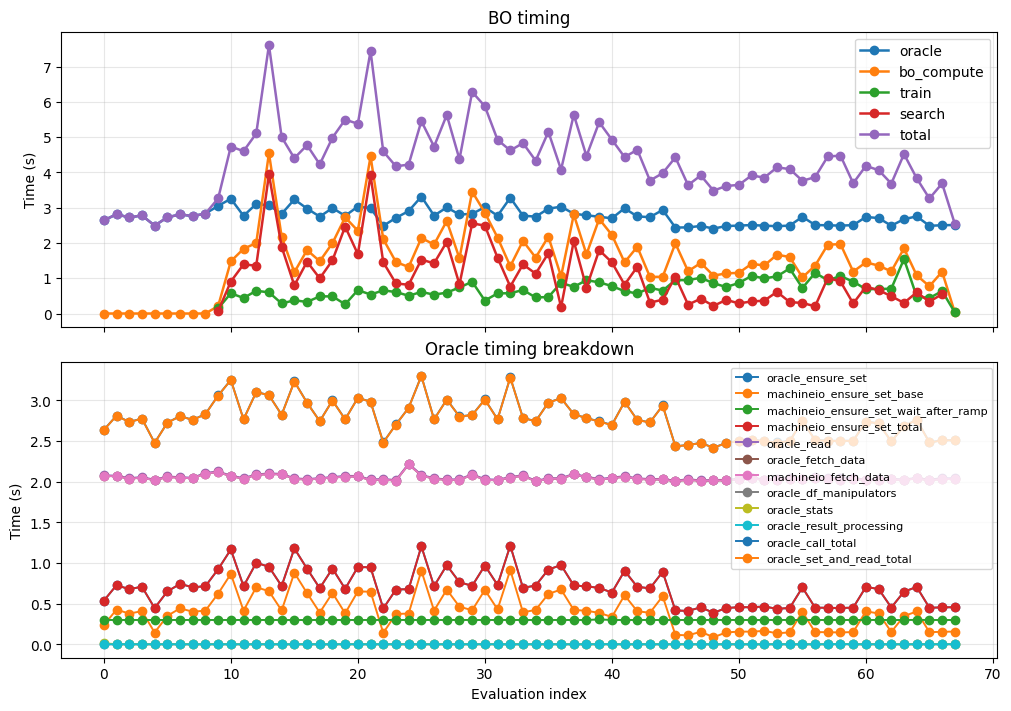

In [30]:
import pandas as pd

timing_df = pd.DataFrame({k: pd.Series(v, dtype="float64") for k, v in bo.timing.items()})
if {"train", "search"}.issubset(timing_df.columns):
    timing_df["bo_compute"] = timing_df["train"].fillna(0.0) + timing_df["search"].fillna(0.0)

display(timing_df.tail())
display(
    timing_df[
        [
            c for c in timing_df.columns
            if c in {"oracle", "train", "search", "total", "bo_compute"}
            or c.startswith("machineio_")
            or c.startswith("oracle_")
        ]
    ].agg(["mean", "median", "max"]).T.sort_values("mean", ascending=False)
)

main_timing_keys = [k for k in ["oracle", "bo_compute", "train", "search", "total"] if k in timing_df.columns]
detail_timing_keys = [
    k for k in [
        "oracle_ensure_set",
        "machineio_ensure_set_base",
        "machineio_ensure_set_wait_after_ramp",
        "machineio_ensure_set_total",
        "oracle_read",
        "oracle_fetch_data",
        "machineio_fetch_data",
        "oracle_df_manipulators",
        "oracle_stats",
        "oracle_result_processing",
        "oracle_call_total",
        "oracle_set_and_read_total",
    ]
    if k in timing_df.columns and timing_df[k].notna().any()
]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
timing_df[main_timing_keys].plot(ax=axes[0], marker="o", linewidth=1.8)
axes[0].set_ylabel("Time (s)")
axes[0].set_title("BO timing")
axes[0].grid(True, alpha=0.3)

if detail_timing_keys:
    timing_df[detail_timing_keys].plot(ax=axes[1], marker="o", linewidth=1.4)
    axes[1].legend(loc="upper right", fontsize=8)
else:
    axes[1].text(0.5, 0.5, "No oracle detail timing keys found", ha="center", va="center", transform=axes[1].transAxes)
axes[1].set_xlabel("Evaluation index")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Oracle timing breakdown")
axes[1].grid(True, alpha=0.3)
plt.show()


# Set to Best solution 

In [31]:
x_hist = [h["x"] for h in bo.history]
y_hist = [h["y"] for h in bo.history]
imax = np.argmax(y_hist)

orcle_dic = oracle(x_hist[imax])

print("Best x:", x_hist[imax])
print("Best y (old):", y_hist[imax])
print("Best y (new):", orcle_dic['y'])

Best x: [ 1.44399032 -0.43906006 -0.97635273 -1.06134868  0.85573971 -0.11015568]
Best y (old): [0.09095964]
Best y (new): [0.09265484]


### comparision: before and after opt

In [32]:
tmp = np.vstack((x_hist[0],x_hist[imax]))
pd.DataFrame(tmp,columns=control_CSETs,index=['before opt','after opt']).T

,before opt,after opt
FE_LEBT:PSC2_D0964:I_CSET,0.099784,1.443990
FE_LEBT:PSC1_D0964:I_CSET,0.175229,-0.439060
FE_LEBT:PSC2_D0979:I_CSET,-0.280136,-0.976353
FE_LEBT:PSC1_D0979:I_CSET,0.106880,-1.061349
FE_LEBT:PSC2_D0992:I_CSET,-0.270828,0.855740
FE_LEBT:PSC1_D0992:I_CSET,-0.250540,-0.110156


## Model mean projection


In [34]:
# # Independent maximum-projection plots of the trained GP posterior mean.
# # This uses BOController.plot_model_pairs directly, not BOController.step(..., plot_acq=True).
# best_x_tensor = torch.as_tensor(x_hist[imax], dtype=bo.bounds.dtype, device=bo.bounds.device)
# bo.plot_model_pairs(
#     dim_names=control_CSETs,
#     n_each=20,
#     project_mode="max",
#     X_candidate=best_x_tensor,
# )
# plt.show()